# Logistic Regression
Logistic regression is a classification algorithm used to assign observations to a discrete set of classes. Unlike linear regression which outputs continuous number values, logistic regression transforms its output using the logistic sigmoid function to return a probability value which can then be mapped to two or more discrete classes.

Logistic regression can be used for:

1. Binary Classification
2. Multi-class Classification
3. One-vs-Rest Classification
> Assumptions of Logistic regression
1. The dependent variable must be categorical in nature.
2. The independent variables(features) must be independent.
3. There should be no outliers in the data. Check for outliers.
4. There should be no high correlations among the independent variables. This can be checked using a correlation matrix.

In [20]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,precision_score,recall_score,f1_score

# Data Loading

In [21]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [22]:
# Create Scaler Object
scaler = StandardScaler()


# Preprocessing 

In [23]:
# 1.Drop Nan Column(Data Cleaning)
# df.drop(columns=['deck'],inplace=True)

# 2.Imputation(Data Cleaning)
df['age'].fillna(df['age'].median(),inplace=True)
df['fare'].fillna(df['fare'].median(),inplace=True)
df['embarked'].fillna(df['embarked'].mode(),inplace=True)
df['embark_town'].fillna(df['embark_town'].mode(),inplace=True)

# 3.Feature Encoding (Discretization)
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        df[col]=LabelEncoder().fit_transform(df[col])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,7,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,2,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,7,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,7,2,0,True


In [24]:
import warnings 
warnings.filterwarnings('ignore')

# Model Train 

In [26]:
# create X and y
X = df.drop('survived',axis=1)
y = df['survived']

# train test split 
X_train , X_test , y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# scale the data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# create the model 
model = LogisticRegression()
model.fit(X,y)

# prediction 
y_pred = model.predict(X_test)

# evaluate the model
print('accuracy score:',accuracy_score(y_test,y_pred))
print('precision score:',precision_score(y_test,y_pred))
print('recall score:',recall_score(y_test,y_pred))
print('f1 score:',f1_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

accuracy score: 1.0
precision score: 1.0
recall score: 1.0
f1 score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179

[[105   0]
 [  0  74]]


# Confusion Matrix Plot

Text(95.72222222222221, 0.5, 'Actual')

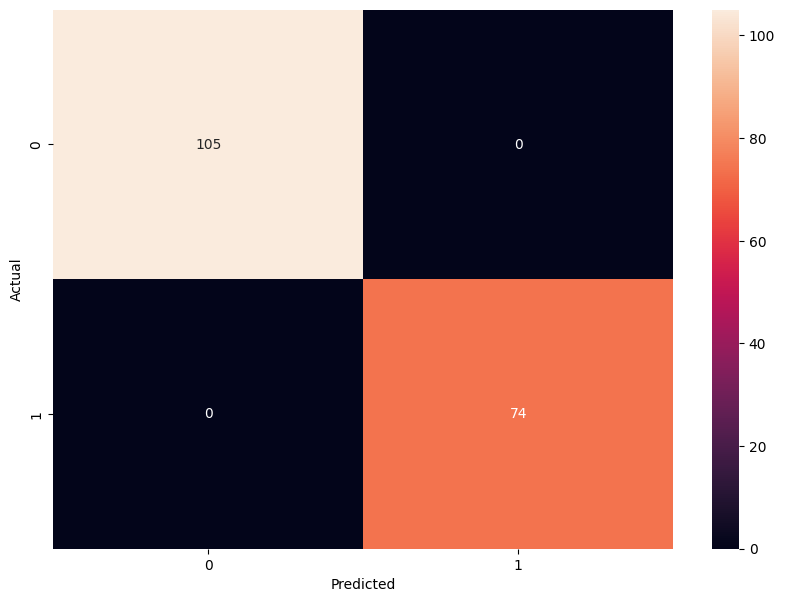

In [28]:
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Save the Model 

In [29]:
import pickle 
pickle.dump(model,open('./saved_models/02_logistic_regression.pkl','wb'))